<a href="https://colab.research.google.com/github/laramalkawi81-ops/DS230-Instacart-Project/blob/main/02_Extended%20EDA%20and%20Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Extended EDA & Data Preprocessing

This notebook focuses on advanced exploratory data analysis,
data cleaning, handling missing values and outliers,
encoding categorical variables, and feature scaling
in preparation for feature engineering and modeling.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = '/content/drive/MyDrive/instacart_data/instacart_data'
orders = pd.read_csv(f"{DATA_PATH}/orders.csv")
products = pd.read_csv(f"{DATA_PATH}/products.csv")
aisles = pd.read_csv(f"{DATA_PATH}/aisles.csv")
departments = pd.read_csv(f"{DATA_PATH}/departments.csv")
order_products_prior = pd.read_csv(f"{DATA_PATH}/order_products__prior.csv")
order_products_train = pd.read_csv(f"{DATA_PATH}/order_products__train.csv")

In [4]:
orders.shape, order_products_prior.shape


((3421083, 7), (32434489, 4))

Missing Values

In [5]:
orders.isnull().sum()


,0
order_id,0
user_id,0
eval_set,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,206209


The only significant missing values appear in `days_since_prior_order`,
which correspond to users' first orders.
Since the absence of a prior order is meaningful,
we impute these values with 0.


In [6]:
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)


Outliers:

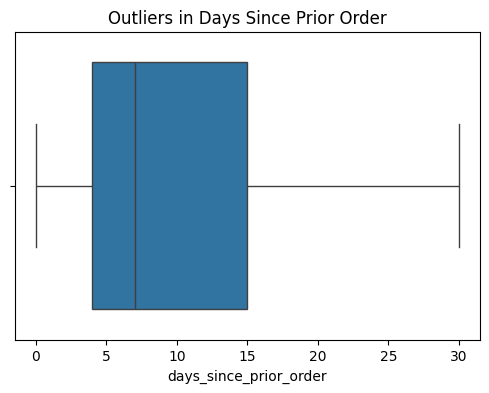

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=orders['days_since_prior_order'])
plt.title("Outliers in Days Since Prior Order")
plt.show()


Extreme values are limited and reflect realistic long gaps between orders.
Therefore, no aggressive outlier removal was applied at this stage.


 Categorical Cardinality :

In [8]:
orders['order_dow'].value_counts()
orders['order_hour_of_day'].value_counts()


,count
order_hour_of_day,
10,288418
11,284728
15,283639
14,283042
13,277999
12,272841
16,272553
9,257812
17,228795


Visualization:

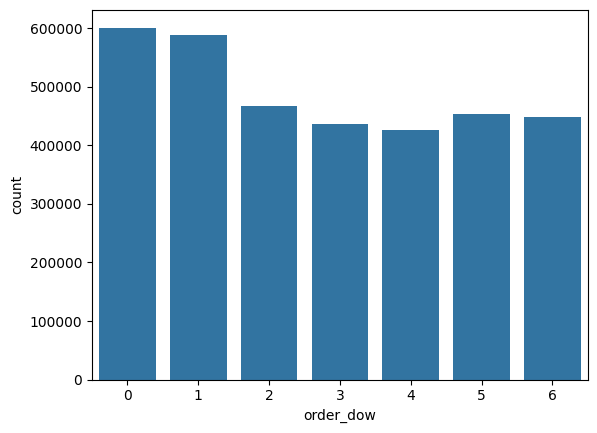

In [9]:
sns.countplot(x='order_dow', data=orders)
plt.show()


Encoding

One-Hot Encoding

In [10]:
orders_encoded = pd.get_dummies(
    orders,
    columns=['order_dow'],
    drop_first=True
)


One-hot encoding was applied to low-cardinality categorical variables
such as day of week to avoid imposing ordinal relationships.


Frequency Encoding (High Cardinality)

In [11]:
product_freq = (
    order_products_prior['product_id']
    .value_counts(normalize=True)
)

order_products_prior['product_freq'] = (
    order_products_prior['product_id']
    .map(product_freq)
)
order_products_prior[['product_id', 'product_freq']].head()



,product_id,product_freq
0,33120,0.000598
1,28985,0.002080
2,9327,0.000194
3,45918,0.000023
4,30035,0.000018


Frequency encoding was applied to high-cardinality variables such as `product_id`.
This approach captures product popularity while avoiding the dimensionality
explosion caused by one-hot encoding.


Correlation Analysis (Numerical Only)

In [12]:
numeric_cols = [
    'order_number',
    'order_hour_of_day',
    'days_since_prior_order'
]

corr_matrix = orders[numeric_cols].corr()


Heatmap drawing

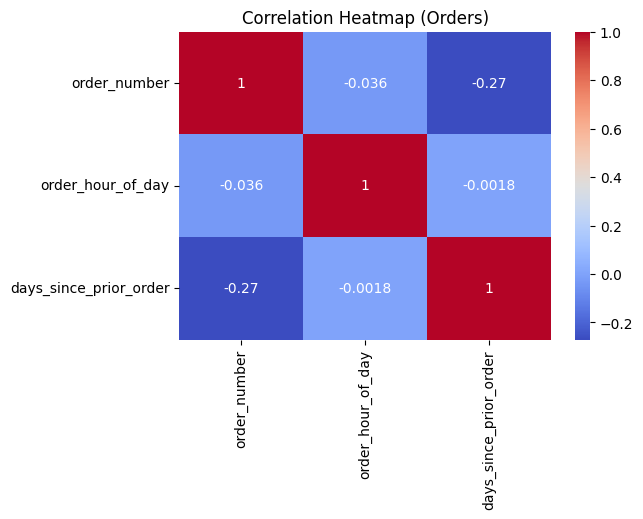

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Orders)")
plt.show()


The correlation analysis shows weak to moderate relationships between
ordering time features and order sequence, suggesting the need for
non-linear and interaction-based features in later stages.


Scaling

Standard Scaling

In [14]:
scaler = StandardScaler()

orders['days_since_prior_order_scaled'] = scaler.fit_transform(
    orders[['days_since_prior_order']]
)
orders[['days_since_prior_order', 'days_since_prior_order_scaled']].head()


,days_since_prior_order,days_since_prior_order_scaled
0,0.0,-1.122053
1,15.0,0.489339
2,21.0,1.133895
3,29.0,1.993304
4,28.0,1.885878


Standard scaling was applied to continuous variables to ensure
comparable feature ranges for distance-based and regularized models.


Target Distribution (Classification Target)

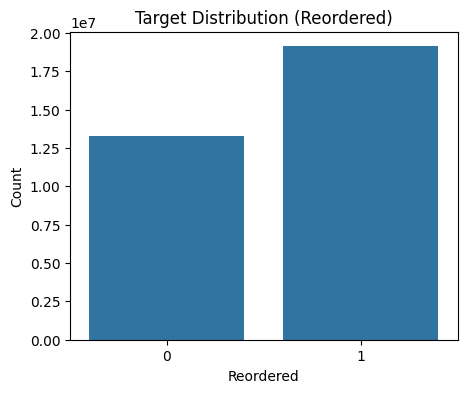

In [15]:
plt.figure(figsize=(5,4))
sns.countplot(x='reordered', data=order_products_prior)
plt.title("Target Distribution (Reordered)")
plt.xlabel("Reordered")
plt.ylabel("Count")
plt.show()


The target variable is highly imbalanced, with non-reordered items
significantly outnumbering reordered ones. This imbalance will be
explicitly handled during model training.


In [17]:
orders.to_csv(f"{DATA_PATH}/orders_clean.csv", index=False)
order_products_prior.to_csv(f"{DATA_PATH}/order_products_prior_clean.csv", index=False)


In this notebook, we performed extended exploratory analysis and
preprocessing, including:
- Handling missing values with domain-aware imputation
- Inspecting and reasoning about outliers
- Encoding categorical variables using one-hot and frequency encoding
- Scaling continuous features
- Analyzing correlations and target imbalance

The cleaned datasets are now ready for feature engineering and modeling,
which will be addressed in File 3.